In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [4]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,1305720,34301264.40,426147.0,15305758.53,2018457.93,782997.60,205805.04,-18995505.87,-124.106922,0.326369,0.446216
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,1476342,34236370.98,480741.0,14457220.47,1684537.11,883315.98,434787.72,-19779150.51,-136.811571,0.325630,0.422277
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,1686663,30764733.12,561420.0,13614361.80,1383420.45,1031562.21,371340.66,-17150371.32,-125.972643,0.332858,0.442531
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,1815138,29350781.46,601236.0,13427918.64,1260150.03,1104728.40,771096.21,-15922862.82,-118.580275,0.331234,0.457498
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,1242981,27208854.09,407514.0,12669322.86,1637334.84,748763.49,771096.21,-14539531.23,-114.761707,0.327852,0.465632


In [5]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10648.0,1.064071e+04,1.870040e+04,2.00,3943.500000,7153.000000,9552.000000,1.733570e+05
Brand,10648.0,1.805450e+04,1.264320e+04,58.00,5816.500000,18776.500000,25521.250000,9.063100e+04
PurchasePrice,10648.0,2.440210e+01,1.094834e+02,0.36,6.840000,10.450000,19.470000,5.681810e+03
ActualPrice,10648.0,3.567118e+01,1.485341e+02,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10648.0,8.478839e+02,6.653542e+02,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10648.0,2.830644e+04,1.000203e+05,9.00,324.000000,2349.000000,17831.250000,3.038940e+06
TotalPurchaseDollars,10648.0,2.712435e+05,1.109494e+06,6.39,4075.717500,32820.525000,186877.530000,3.430126e+07
TotalSalesQuantity,10648.0,9.245706e+03,3.291322e+04,0.00,99.000000,781.500000,5802.750000,1.004817e+06
TotalSalesDollars,10648.0,1.269088e+05,5.038418e+05,0.00,2184.825000,15857.745000,85242.150000,1.530576e+07
TotalSalesPrice,10648.0,5.644094e+04,1.350552e+05,0.00,866.490000,8525.325000,48240.810000,2.018458e+06


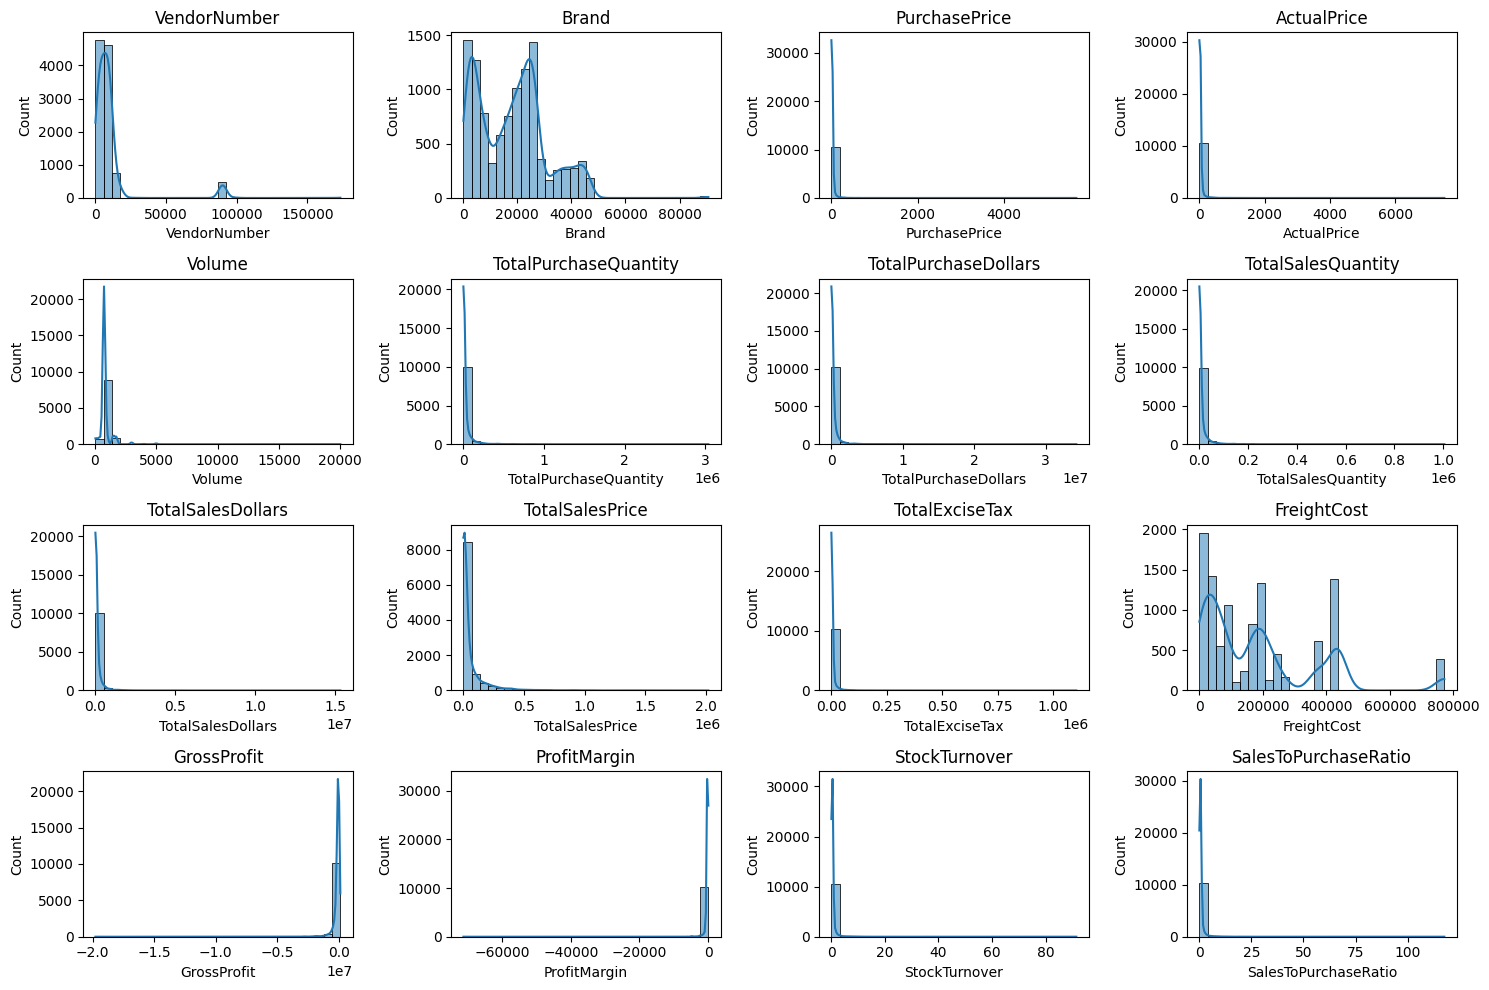

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Create distribution plots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # adjust grid size if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


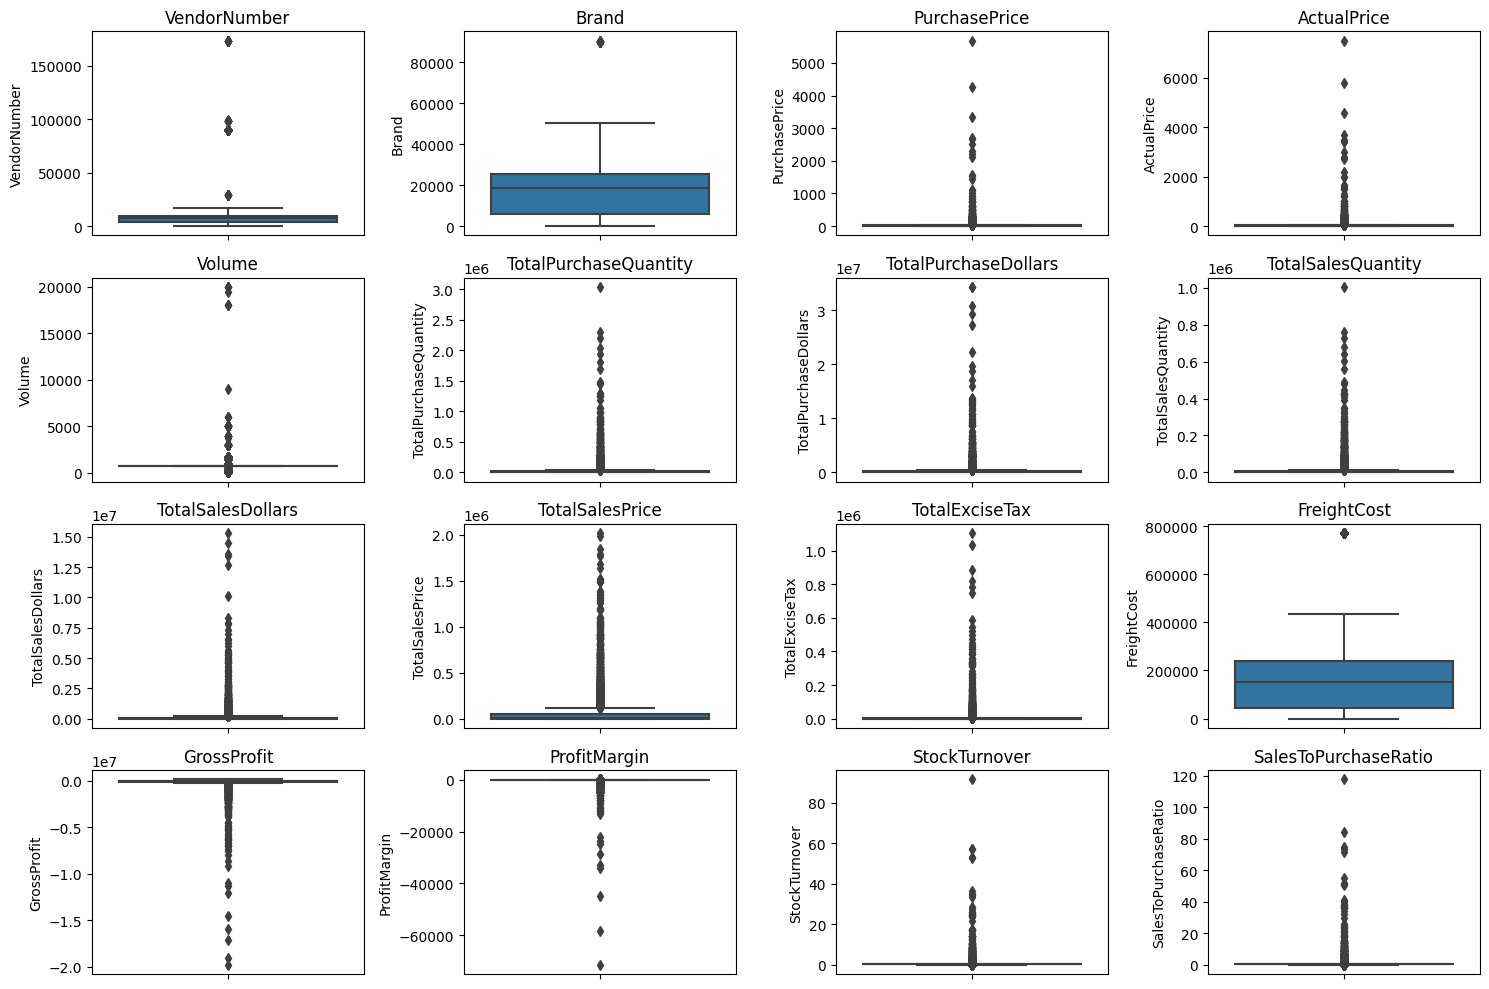

In [7]:
# boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # adjust grid size if needed
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [8]:
df = pd.read_sql_query("""SELECT * 
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""", conn)

In [9]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,8112,MOET HENNESSY USA INC,1023,Hennessy VSOP Cognac + 50mL,35.93,45.99,750.0,6840,245761.20,5535.0,275119.65,68065.20,4359.33,145041.78,29358.45,10.671157,0.809211,1.119459
1,10754,PERFECTA WINES,2208,WhistlePig 10 Yr Old Rye,53.95,74.99,750.0,4545,245202.75,5271.0,386317.29,215160.93,4153.44,86161.56,141114.54,36.528145,1.159736,1.575501
2,1128,BROWN-FORMAN CORP,1771,Jack Daniels Tennessee Fire,0.75,0.99,50.0,270000,202500.00,70917.0,212041.83,69167.67,3682.89,205805.04,9541.83,4.499975,0.262656,1.047120
3,4425,MARTIGNETTI COMPANIES,18950,Schug Pnt Nr Carneros,12.32,17.99,750.0,14004,172529.28,9708.0,174646.92,73183.32,1083.57,434787.72,2117.64,1.212526,0.693231,1.012274
4,9165,ULTRA BEVERAGE COMPANY LLP,28457,Clos Pegase Merlot Napa,11.76,17.99,750.0,12897,151668.72,8820.0,158671.80,71564.22,982.74,204164.10,7003.08,4.413563,0.683880,1.046174
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,18,25.56,42.0,83.58,17.91,2.19,771096.21,58.02,69.418521,2.333333,3.269953
1161,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,18,23.76,15.0,47.85,32.88,1.65,81301.23,24.09,50.344828,0.833333,2.013889
1162,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,54,21.06,402.0,196.98,4.41,21.12,150880.86,175.92,89.308559,7.444444,9.353276
1163,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,9,13.23,216.0,429.84,232.83,45.36,771096.21,416.61,96.922111,24.000000,32.489796


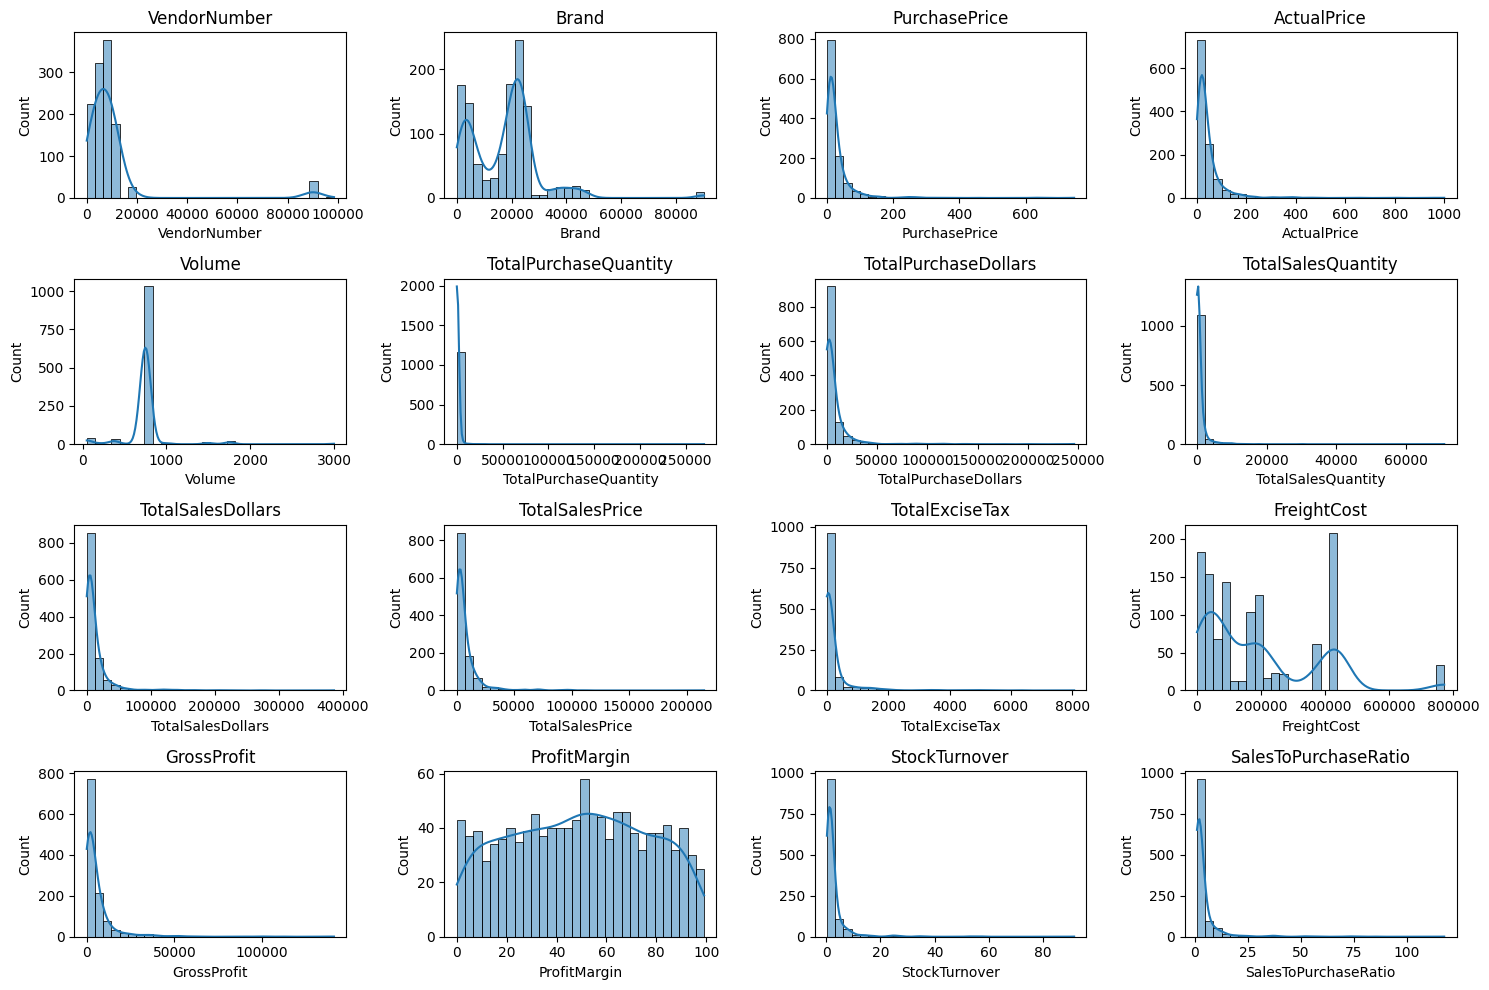

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

# Create distribution plots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1)   # adjust grid size if needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()


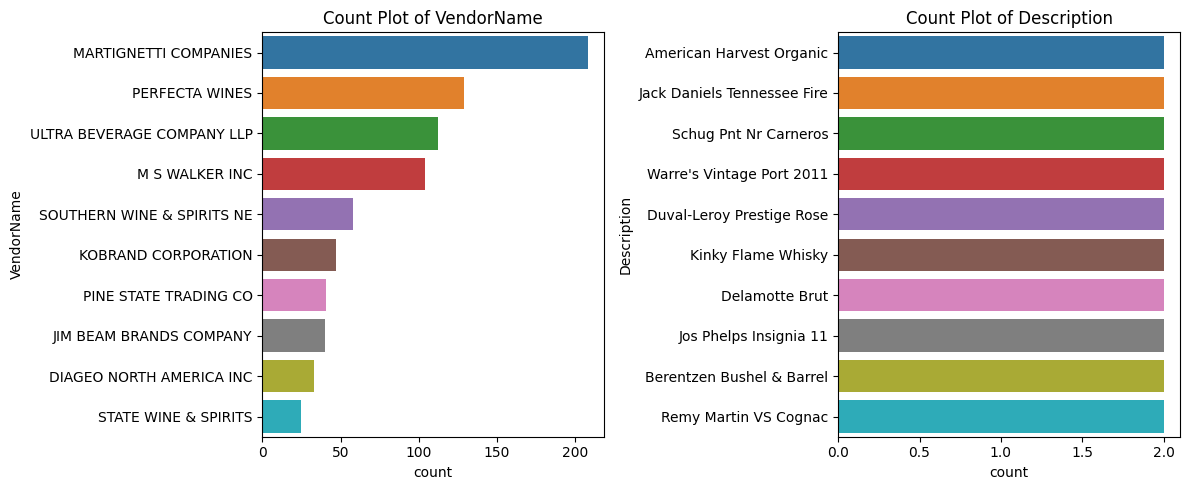

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i + 1)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().index[:10]  # Top 10 categories
    )
    plt.title(f"Count Plot of {col}")

plt.tight_layout()
plt.show()


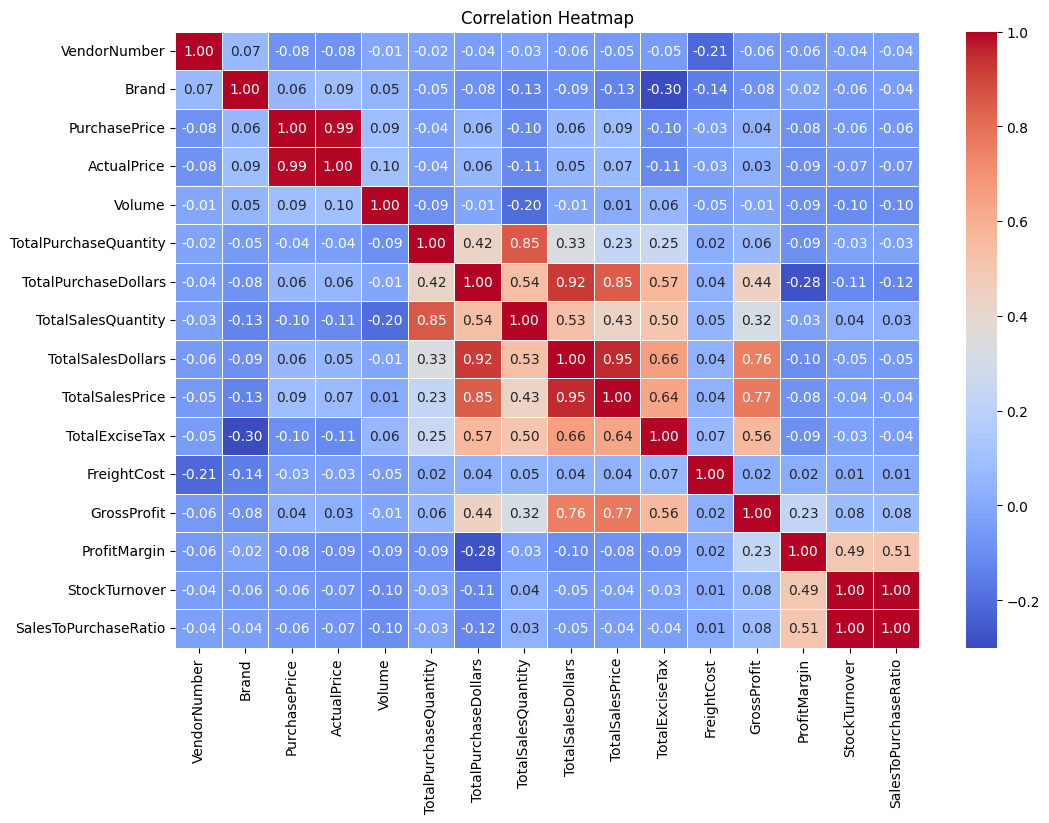

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation Heatmap
plt.figure(figsize=(12, 8))

correlation_matrix = df[numerical_cols].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()


📊 Correlation Insights from Vendor Sales Analysis

The correlation heatmap helps understand how different sales, purchase, and profitability variables are related to each other.

1️⃣ Strong Positive Correlations

PurchasePrice and ActualPrice (≈ 0.99)
These two variables are almost perfectly correlated, indicating that the listed purchase price closely matches the actual price paid to vendors.

TotalSalesDollars and TotalSalesPrice (≈ 0.95)
Higher sales prices directly result in higher total sales revenue, which is expected in a sales-driven system.

TotalPurchaseDollars and TotalSalesDollars (≈ 0.92)
Vendors with higher purchase investments also tend to generate higher sales revenue.

StockTurnover and SalesToPurchaseRatio (≈ 1.00)
This perfect correlation shows that vendors who sell stock faster also maintain a strong balance between sales and purchase value.

2️⃣ Moderate Positive Relationships

TotalSalesQuantity with TotalPurchaseQuantity (≈ 0.85)
Higher purchase quantities generally lead to higher sales quantities, indicating efficient inventory movement.

GrossProfit with TotalSalesDollars (≈ 0.76)
Increased sales revenue contributes significantly to higher gross profit.

ProfitMargin with StockTurnover (≈ 0.49)
Vendors with faster inventory turnover tend to achieve better profit margins.

In [13]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()

In [14]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.15)

In [15]:
low_sales_threshold

1451.109

In [16]:
high_margin_threshold

16.38309631782488

In [17]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]

print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))


Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
356,Concannon Glen Ellen Wh Zin,47.85,50.344828
374,Crown Royal Apple,83.58,69.418521
916,Sauza Sprklg Wild Berry Marg,83.88,46.459227
723,Merry Irish Cream Liqueur,107.91,20.600500
1070,Tracia Syrah,134.82,65.487316
...,...,...,...
155,Capt Morgan White Pineapple,1413.72,29.036160
509,Gran Gala Liqueur,1428.57,50.727651
965,Smashberry Red,1432.80,16.494975
331,Chicken & Turkey Cotes du Rh,1438.41,29.046656


In [18]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000]

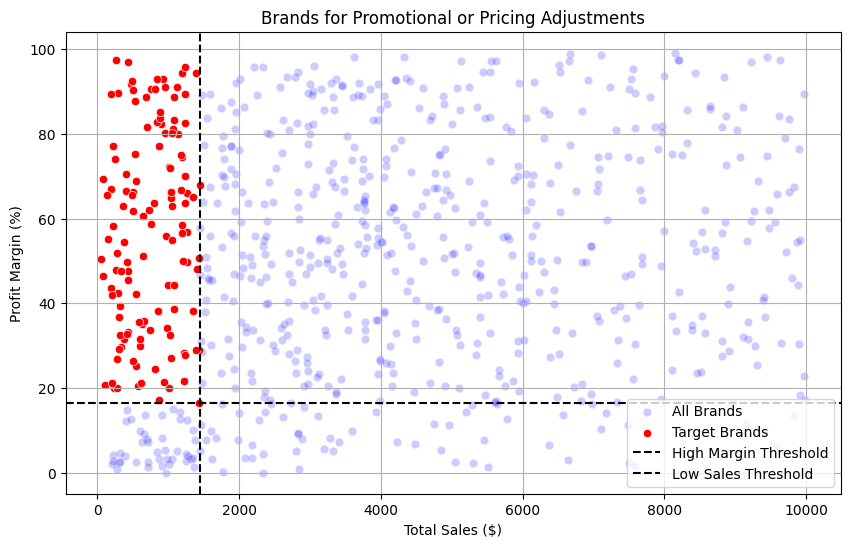

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=brand_performance,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='blue',
    label='All Brands',
    alpha=0.2
)

sns.scatterplot(
    data=target_brands,
    x='TotalSalesDollars',
    y='ProfitMargin',
    color='red',
    label='Target Brands'
)

plt.axhline(
    high_margin_threshold,
    linestyle='--',
    color='black',
    label='High Margin Threshold'
)

plt.axvline(
    low_sales_threshold,
    linestyle='--',
    color='black',
    label='Low Sales Threshold'
)

plt.xlabel('Total Sales ($)')
plt.ylabel('Profit Margin (%)')
plt.title('Brands for Promotional or Pricing Adjustments')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)


In [21]:
# Top Vendors & Brands by Sales Performance

top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)

top_vendors, top_brands


(VendorName
 MARTIGNETTI COMPANIES         2893591.23
 ULTRA BEVERAGE COMPANY LLP    1723235.82
 PERFECTA WINES                1407284.76
 M S WALKER INC                1204770.27
 BACARDI USA INC                704113.35
 BROWN-FORMAN CORP              601926.63
 SOUTHERN WINE & SPIRITS NE     571023.21
 JIM BEAM BRANDS COMPANY        504570.09
 STATE WINE & SPIRITS           487348.32
 DIAGEO NORTH AMERICA INC       448502.82
 Name: TotalSalesDollars, dtype: float64,
 Description
 WhistlePig 10 Yr Old Rye        386317.29
 Hennessy VSOP Cognac + 50mL     275119.65
 Jack Daniels Tennessee Fire     243283.53
 Bacardi Twin Pack 2/750mls      201761.70
 Schug Pnt Nr Carneros           193967.34
 Jeffersons  Ocean Bourbon       193655.79
 DiSaronna Amaretto Sour VAP     170825.67
 Jack Daniels No 7 Black Trav    159348.33
 Clos Pegase Merlot Napa         158671.80
 American Harvest Organic        155688.27
 Name: TotalSalesDollars, dtype: float64)

In [22]:
top_brands

Description
WhistlePig 10 Yr Old Rye        386317.29
Hennessy VSOP Cognac + 50mL     275119.65
Jack Daniels Tennessee Fire     243283.53
Bacardi Twin Pack 2/750mls      201761.70
Schug Pnt Nr Carneros           193967.34
Jeffersons  Ocean Bourbon       193655.79
DiSaronna Amaretto Sour VAP     170825.67
Jack Daniels No 7 Black Trav    159348.33
Clos Pegase Merlot Napa         158671.80
American Harvest Organic        155688.27
Name: TotalSalesDollars, dtype: float64

In [23]:
top_brands.apply(lambda x : format_dollars(x))

Description
WhistlePig 10 Yr Old Rye        386.32K
Hennessy VSOP Cognac + 50mL     275.12K
Jack Daniels Tennessee Fire     243.28K
Bacardi Twin Pack 2/750mls      201.76K
Schug Pnt Nr Carneros           193.97K
Jeffersons  Ocean Bourbon       193.66K
DiSaronna Amaretto Sour VAP     170.83K
Jack Daniels No 7 Black Trav    159.35K
Clos Pegase Merlot Napa         158.67K
American Harvest Organic        155.69K
Name: TotalSalesDollars, dtype: object

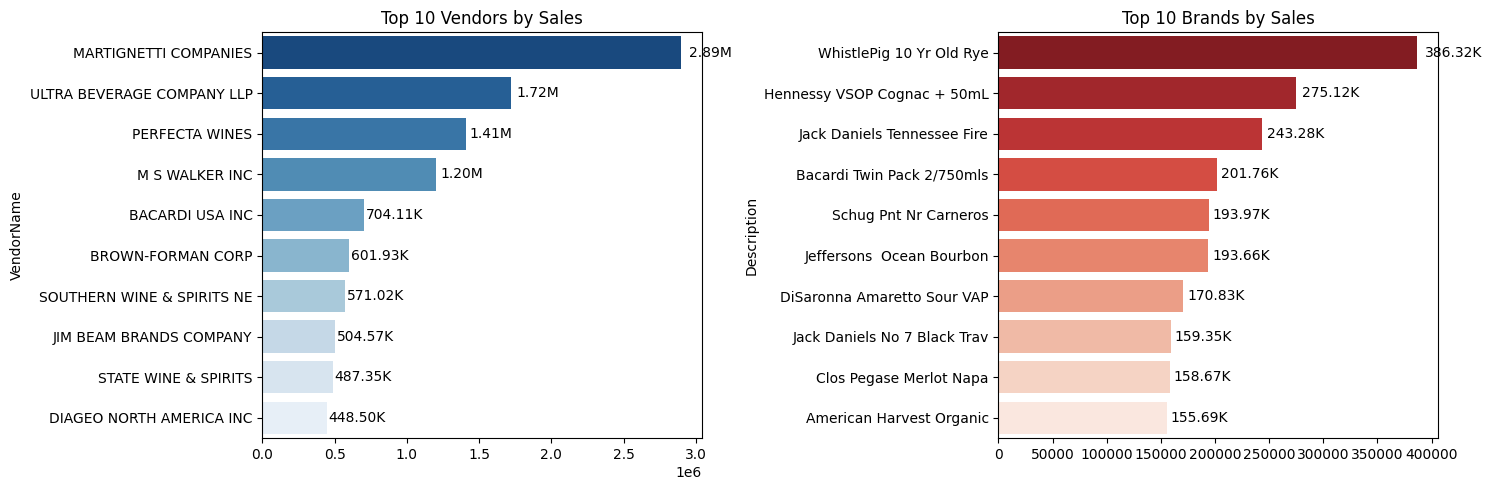

In [24]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

# Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha='left',
        va='center',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()


In [25]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(73, 4)

In [26]:
vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars'] /
    vendor_performance['TotalPurchaseDollars'].sum()*100
)


In [27]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False),2)

In [28]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10)

top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)

top_vendors


,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
32,MARTIGNETTI COMPANIES,1.65M,1.24M,2.89M,18.65
65,ULTRA BEVERAGE COMPANY LLP,984.35K,738.89K,1.72M,11.12
41,PERFECTA WINES,799.60K,607.68K,1.41M,9.04
30,M S WALKER INC,598.14K,606.63K,1.20M,6.76
36,MOET HENNESSY USA INC,362.96K,78.72K,441.69K,4.10
24,JIM BEAM BRANDS COMPANY,341.42K,163.15K,504.57K,3.86
4,BROWN-FORMAN CORP,319.02K,282.90K,601.93K,3.61
13,DIAGEO NORTH AMERICA INC,305.32K,143.18K,448.50K,3.45
57,STATE WINE & SPIRITS,299.50K,187.85K,487.35K,3.38
2,BACARDI USA INC,298.26K,405.85K,704.11K,3.37


In [29]:
top_vendors['PurchaseContribution%'].sum()

67.33999999999999

In [30]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
32,MARTIGNETTI COMPANIES,1.65M,1.24M,2.89M,18.65,18.65
65,ULTRA BEVERAGE COMPANY LLP,984.35K,738.89K,1.72M,11.12,29.77
41,PERFECTA WINES,799.60K,607.68K,1.41M,9.04,38.81
30,M S WALKER INC,598.14K,606.63K,1.20M,6.76,45.57
36,MOET HENNESSY USA INC,362.96K,78.72K,441.69K,4.10,49.67
24,JIM BEAM BRANDS COMPANY,341.42K,163.15K,504.57K,3.86,53.53
4,BROWN-FORMAN CORP,319.02K,282.90K,601.93K,3.61,57.14
13,DIAGEO NORTH AMERICA INC,305.32K,143.18K,448.50K,3.45,60.59
57,STATE WINE & SPIRITS,299.50K,187.85K,487.35K,3.38,63.97
2,BACARDI USA INC,298.26K,405.85K,704.11K,3.37,67.34


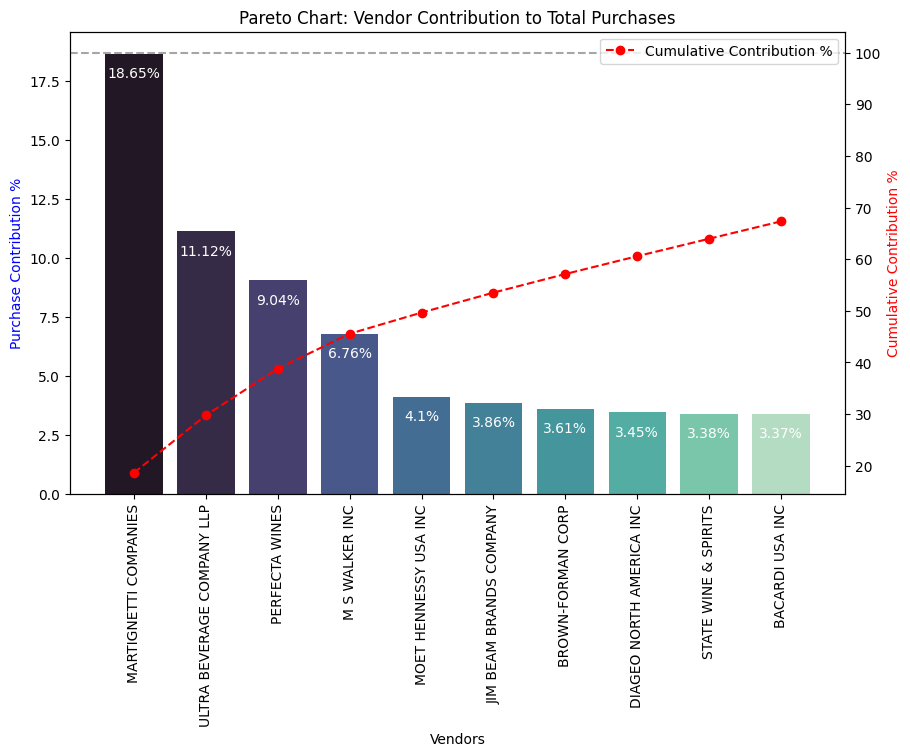

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['PurchaseContribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()
ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()


In [32]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(), 2)} %")


Total Purchase Contribution of top 10 vendors is 67.34 %


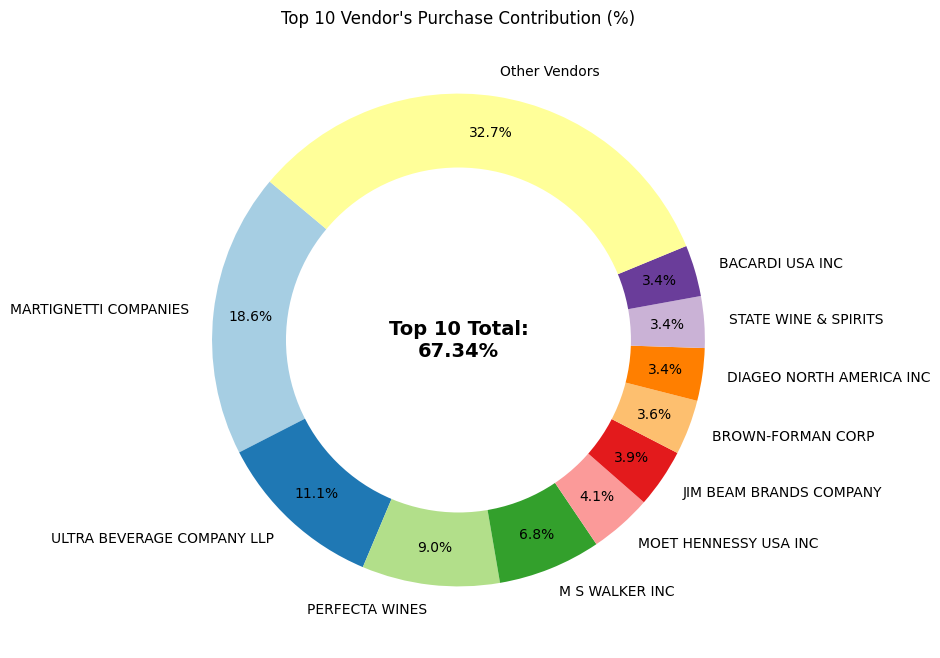

In [33]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()


In [34]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [35]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio,UnitPurchasePrice
0,8112,MOET HENNESSY USA INC,1023,Hennessy VSOP Cognac + 50mL,35.93,45.99,750.0,6840,245761.20,5535.0,275119.65,68065.20,4359.33,145041.78,29358.45,10.671157,0.809211,1.119459,35.93
1,10754,PERFECTA WINES,2208,WhistlePig 10 Yr Old Rye,53.95,74.99,750.0,4545,245202.75,5271.0,386317.29,215160.93,4153.44,86161.56,141114.54,36.528145,1.159736,1.575501,53.95
2,1128,BROWN-FORMAN CORP,1771,Jack Daniels Tennessee Fire,0.75,0.99,50.0,270000,202500.00,70917.0,212041.83,69167.67,3682.89,205805.04,9541.83,4.499975,0.262656,1.047120,0.75
3,4425,MARTIGNETTI COMPANIES,18950,Schug Pnt Nr Carneros,12.32,17.99,750.0,14004,172529.28,9708.0,174646.92,73183.32,1083.57,434787.72,2117.64,1.212526,0.693231,1.012274,12.32
4,9165,ULTRA BEVERAGE COMPANY LLP,28457,Clos Pegase Merlot Napa,11.76,17.99,750.0,12897,151668.72,8820.0,158671.80,71564.22,982.74,204164.10,7003.08,4.413563,0.683880,1.046174,11.76
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,18,25.56,42.0,83.58,17.91,2.19,771096.21,58.02,69.418521,2.333333,3.269953,1.42
1161,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,18,23.76,15.0,47.85,32.88,1.65,81301.23,24.09,50.344828,0.833333,2.013889,1.32
1162,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,54,21.06,402.0,196.98,4.41,21.12,150880.86,175.92,89.308559,7.444444,9.353276,0.39
1163,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,9,13.23,216.0,429.84,232.83,45.36,771096.21,416.61,96.922111,24.000000,32.489796,1.47


In [36]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

df[["OrderSize" , "TotalPurchaseQuantity"]]


,OrderSize,TotalPurchaseQuantity
0,Large,6840
1,Large,4545
2,Large,270000
3,Large,14004
4,Large,12897
...,...,...
1160,Small,18
1161,Small,18
1162,Small,54
1163,Small,9


In [37]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,45.242598
Medium,28.297399
Large,13.530026


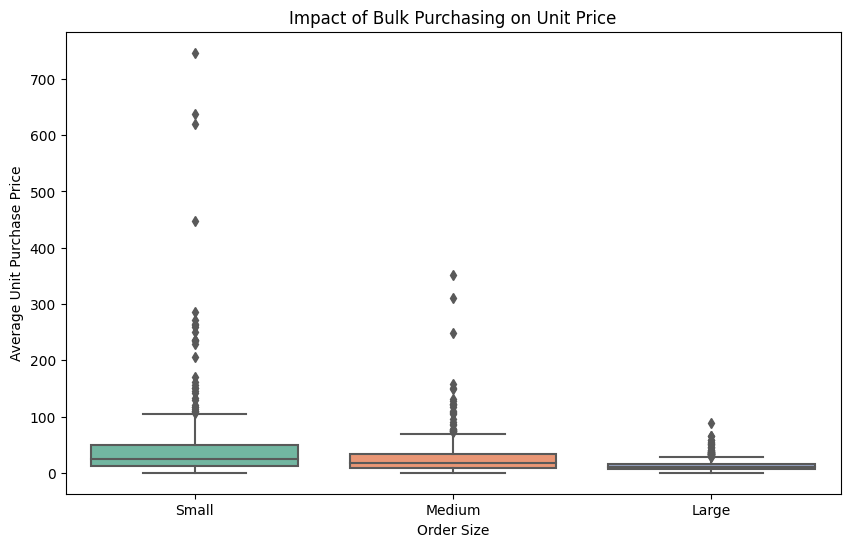

In [38]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.show()


In [39]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending = True).head(10)

,StockTurnover
VendorName,
DELICATO VINEYARDS INC,0.333333
FORTUNE WINE BROKERS LLC,0.593220
STE MICHELLE WINE ESTATES,0.660985
CONSTELLATION BRANDS INC,0.664894
E & J GALLO WINERY,0.665304
DIAGEO CHATEAU ESTATE WINES,0.670733
SEA BREEZE CELLARS LLC,0.706250
BROWN-FORMAN CORP,0.716420
FREDERICK WILDMAN & SONS,0.732143


In [40]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))


Total Unsold Capital: -1941900.39


In [41]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(format_dollars)
inventory_value_per_vendor.head(10)


,VendorName,UnsoldInventoryValue
36,MOET HENNESSY USA INC,38.15K
12,DIAGEO CHATEAU ESTATE WINES,35.15K
64,TRINCHERO FAMILY ESTATES,14.61K
63,TREASURY WINE ESTATES,13.40K
43,PHILLIPS PRODUCTS CO.,8.46K
52,SEA BREEZE CELLARS LLC,6.76K
69,VRANKEN AMERICA,3.95K
27,LABELLE VYDS AND WINERY,3.76K
51,SAZERAC NORTH AMERICA INC.,1.96K
56,STAR INDUSTRIES INC.,1.45K


In [42]:
top_threshold = df["TotalSalesDollars"].quantile(0.75) 
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [43]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna() 
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [44]:
top_vendors

0       10.671157
1       36.528145
2        4.499975
3        1.212526
4        4.413563
          ...    
816     93.528470
942     97.550691
975     96.609318
1084    98.602679
1090    98.659739
Name: ProfitMargin, Length: 292, dtype: float64

In [45]:
low_vendors

586      0.001282
600      8.049042
601      4.514855
616      3.448276
622     16.115034
          ...    
1160    69.418521
1161    50.344828
1162    89.308559
1163    96.922111
1164    97.498238
Name: ProfitMargin, Length: 292, dtype: float64

In [46]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))  # Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% CI: (40.96, 47.23), Mean: 44.10
Low Vendors 95% CI: (42.11, 48.72), Mean: 45.41


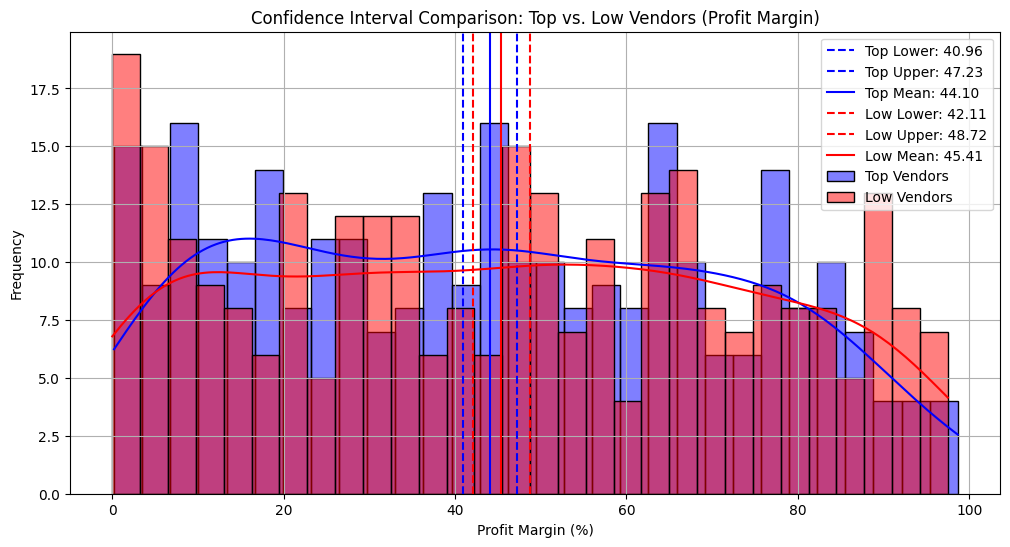

In [47]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# Top Vendors Plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [48]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

# Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results
print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H₀: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H₀: No significant difference in profit margins.")


T-Statistic: -0.5687, P-Value: 0.5698
Fail to Reject H₀: No significant difference in profit margins.


In [50]:
df.to_csv("vendor_summary_dashboard.csv", index=False)

print("CSV file exported successfully!")

CSV file exported successfully!
